# Sperm Motility Analysis Pipeline — Single-Video Demo

This notebook walks through the **complete pipeline** on a single VISEM-Tracking video,
from raw data to clinical report.

**Pipeline stages:**
1. Setup & Configuration
2. Data Exploration — inspect the raw VISEM video and annotations
3. Detection — run YOLOv8 sperm detector (or use ground-truth annotations)
4. Tracking — BoT-SORT multi-object tracking
5. Motility Analysis — WHO 2021 kinematic metrics & classification
6. Quality Filtering — remove spurious tracks
7. Visualisation — trajectories, motility charts, velocity heatmap
8. Clinical Report — LLM or template-based semen analysis report
9. Evaluation — compare against clinical ground truth

**Dataset:** [VISEM-Tracking](https://zenodo.org/records/7293726) — 20 videos, 640×480, 50 fps, ~30 s each  
**Demo video:** Video 14 (from the val split)

## 1. Setup & Configuration

In [1]:
import sys, os
from pathlib import Path

# Ensure we're in the project root
PROJECT_ROOT = Path("/mnt/nas1/nba055-2/WP4_/sperm_analysis")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

import config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import json
from IPython.display import display, Markdown, Image

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

# ── Choose the demo video ──
VIDEO_ID = "14"

print(f"Project root:       {config.PROJECT_ROOT}")
print(f"VISEM data root:    {config.VISEM_ROOT}")
print(f"Pixels per µm:      {config.PIXELS_PER_MICRON}")
print(f"FPS:                {config.FPS}")
print(f"WHO thresholds:")
print(f"  VCL progressive ≥ {config.VCL_PROGRESSIVE_MIN} µm/s")
print(f"  STR progressive ≥ {config.STR_PROGRESSIVE_MIN}")
print(f"  VCL immotile    ≤ {config.VCL_IMMOTILE_MAX} µm/s")
print(f"  Min track length: {config.MIN_TRACK_LENGTH} frames")

/home/idl-nba055/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/idl-nba055/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Project root:       /mnt/nas1/nba055-2/WP4_/sperm_analysis
VISEM data root:    /mnt/nas1/nba055-2/WP4_/sperm_analysis/data/raw/VISEM_Tracking_Train_v4/Train
Pixels per µm:      1.422
FPS:                50
WHO thresholds:
  VCL progressive ≥ 25.0 µm/s
  STR progressive ≥ 0.5
  VCL immotile    ≤ 5.0 µm/s
  Min track length: 10 frames


## 2. Data Exploration

Each VISEM video directory contains:
- `{id}.mp4` — the microscopy video
- `images/` — pre-extracted JPEG frames
- `labels/` — YOLO-format bounding-box annotations
- `labels_ftid/` — annotations with feature track IDs (ground-truth tracking)

In [2]:
video_dir = config.VISEM_ROOT / VIDEO_ID
print(f"Video directory: {video_dir}")
print(f"Contents: {sorted(os.listdir(video_dir))}")

# Count frames and annotations
images_dir = video_dir / "images"
labels_dir = video_dir / "labels"
labels_ftid_dir = video_dir / "labels_ftid"

n_frames = len(list(images_dir.glob("*.jpg")))
n_labels = len(list(labels_dir.glob("*.txt")))
n_ftid   = len(list(labels_ftid_dir.glob("*.txt")))
print(f"\nFrames:            {n_frames}")
print(f"Label files:       {n_labels}")
print(f"Track-ID labels:   {n_ftid}")
print(f"Duration:          {n_frames / config.FPS:.1f} s @ {config.FPS} fps")

Video directory: /mnt/nas1/nba055-2/WP4_/sperm_analysis/data/raw/VISEM_Tracking_Train_v4/Train/14
Contents: ['14.mp4', '14.txt', 'images', 'labels', 'labels_ftid']

Frames:            1470
Label files:       1470
Track-ID labels:   1470
Duration:          29.4 s @ 50 fps


Frame shape: 640×480
Detections in first frame: 3
Sample line (YOLO format): 0 0.20859375 0.825 0.0359375 0.0375


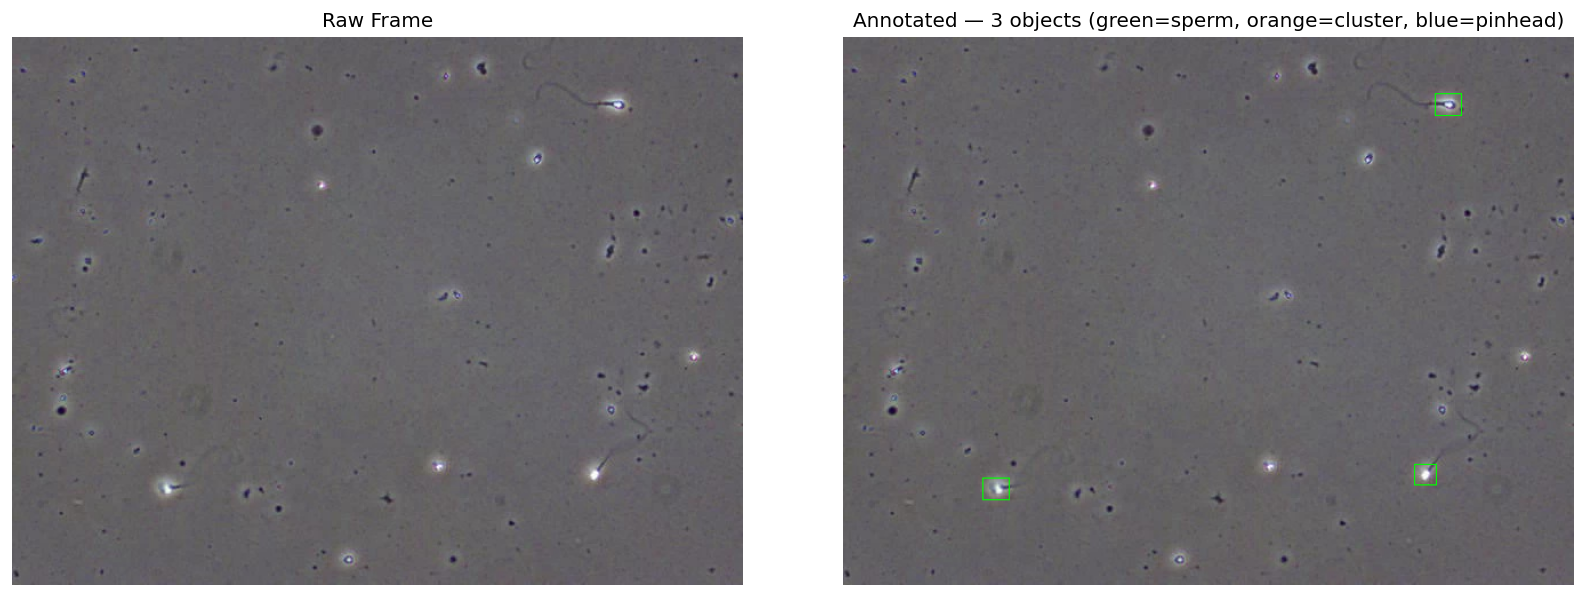

In [3]:
# Show a sample frame with annotations overlaid
sample_frame_path = sorted(images_dir.glob("*.jpg"))[0]
frame = cv2.imread(str(sample_frame_path))
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
h, w = frame.shape[:2]
print(f"Frame shape: {w}×{h}")

# Parse corresponding label file
label_name = sample_frame_path.stem + ".txt"
label_path = labels_dir / label_name
if label_path.exists():
    with open(label_path) as f:
        lines = f.readlines()
    print(f"Detections in first frame: {len(lines)}")
    print(f"Sample line (YOLO format): {lines[0].strip()}")
    
    # Draw bounding boxes
    colors = {0: (0, 255, 0), 1: (255, 165, 0), 2: (0, 0, 255)}  # sperm, cluster, pinhead
    class_names = config.CLASS_NAMES
    for line in lines:
        parts = line.strip().split()
        cls = int(parts[0])
        cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
        x1 = int((cx - bw/2) * w)
        y1 = int((cy - bh/2) * h)
        x2 = int((cx + bw/2) * w)
        y2 = int((cy + bh/2) * h)
        color = colors.get(cls, (255, 255, 255))
        cv2.rectangle(frame_rgb, (x1, y1), (x2, y2), color, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(cv2.cvtColor(cv2.imread(str(sample_frame_path)), cv2.COLOR_BGR2RGB))
axes[0].set_title("Raw Frame")
axes[0].axis("off")
axes[1].imshow(frame_rgb)
axes[1].set_title(f"Annotated — {len(lines)} objects (green=sperm, orange=cluster, blue=pinhead)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [4]:
# Peek at the track-ID annotation format
ftid_files = sorted(labels_ftid_dir.glob("*.txt"))
print(f"First track-ID label: {ftid_files[0].name}")
with open(ftid_files[0]) as f:
    ftid_lines = f.readlines()[:5]
print("Format: <feature_id> <class> <cx> <cy> <w> <h>")
for line in ftid_lines:
    print(f"  {line.strip()}")

First track-ID label: 14_frame_0_with_ftid.txt
Format: <feature_id> <class> <cx> <cy> <w> <h>
  ckyw6zzlj001r3867thf0fuy7 0 0.20859375 0.825 0.0359375 0.0375
  ckyw704kw001v3867kvyjtx6k 0 0.79609375 0.7979166666666667 0.0296875 0.0375
  ckyw708pn001z386779fr849h 0 0.82734375 0.12395833333333334 0.0359375 0.03958333333333333


## 3. Ground-Truth Track Parsing

For this demo we use the **ground-truth annotations** (from `labels_ftid/`) so
the pipeline is not dependent on model weights. In production, Stages 3–4 would
use `detection/detect_sperm.predict_video_frames()` → `tracking/track_sperm.track_from_frames()`.

The GT parser reads feature-track IDs, denormalises coordinates, and produces a
tracking CSV identical in format to what the YOLO+BoT-SORT pipeline outputs.

In [5]:
from run_single_gt import parse_gt_tracks

tracks_df = parse_gt_tracks(VIDEO_ID)
print(f"Tracks CSV saved → {config.TRACK_OUT / f'{VIDEO_ID}_tracks.csv'}")
print(f"\nShape: {tracks_df.shape}")
print(f"Columns: {tracks_df.columns.tolist()}")
print(f"Unique tracks: {tracks_df['track_id'].nunique()}")
print(f"Frame range: {tracks_df['frame'].min()} – {tracks_df['frame'].max()}")
print(f"Confidence (GT): {tracks_df['conf'].unique()}")
tracks_df.head(10)

  Image size: 640×480
  Annotation files: 1470


  → 8 unique tracks across 1470 frames (5750 detections)
  → Saved: /mnt/nas1/nba055-2/WP4_/sperm_analysis/outputs/tracks/14_tracks.csv
  Track lengths: min=619, median=721, max=749, mean=718.8
Tracks CSV saved → /mnt/nas1/nba055-2/WP4_/sperm_analysis/outputs/tracks/14_tracks.csv

Shape: (5750, 9)
Columns: ['track_id', 'frame', 'cx', 'cy', 'x1', 'y1', 'x2', 'y2', 'conf']
Unique tracks: 8
Frame range: 0 – 1469
Confidence (GT): [1.]


,track_id,frame,cx,cy,x1,y1,x2,y2,conf
0,1,0,133.5,396.0,122.0,387.0,145.0,405.0,1.0
1,1,1,133.5,391.0,122.0,382.0,145.0,400.0,1.0
2,1,2,101.5,336.0,90.0,327.0,113.0,345.0,1.0
3,1,3,101.3,333.2,89.8,324.2,112.8,342.2,1.0
4,1,4,101.1,330.4,89.6,321.4,112.6,339.4,1.0
5,1,5,100.9,327.6,89.4,318.6,112.4,336.6,1.0
6,1,6,100.7,324.8,89.2,315.8,112.2,333.8,1.0
7,1,7,100.5,322.0,89.0,313.0,112.0,331.0,1.0
8,1,8,102.5,319.6,91.0,310.6,114.0,328.6,1.0
9,1,9,104.5,317.2,93.0,308.2,116.0,326.2,1.0


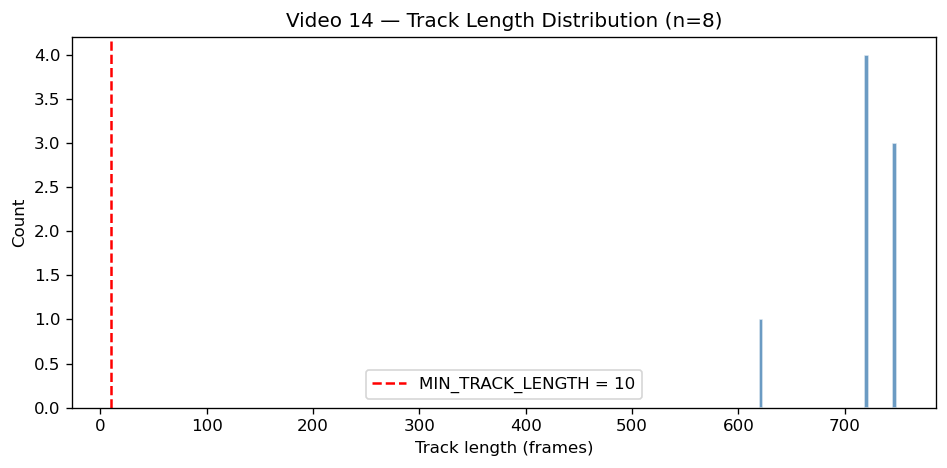

Tracks ≥ 10 frames: 8
Tracks < 10 frames: 0 (will be excluded)


In [6]:
# Track length distribution
track_lengths = tracks_df.groupby("track_id").size()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(track_lengths, bins=30, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(config.MIN_TRACK_LENGTH, color="red", linestyle="--",
           label=f"MIN_TRACK_LENGTH = {config.MIN_TRACK_LENGTH}")
ax.set_xlabel("Track length (frames)")
ax.set_ylabel("Count")
ax.set_title(f"Video {VIDEO_ID} — Track Length Distribution (n={len(track_lengths)})")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Tracks ≥ {config.MIN_TRACK_LENGTH} frames: {(track_lengths >= config.MIN_TRACK_LENGTH).sum()}")
print(f"Tracks < {config.MIN_TRACK_LENGTH} frames: {(track_lengths < config.MIN_TRACK_LENGTH).sum()} (will be excluded)")

## 4. YOLO Detection + BoT-SORT Tracking (Alternative Path)

Below shows how to run the **model-based** detection and tracking path.
Uncomment to run it instead of the GT annotations above.

```python
# Requires trained weights at detection/weights/best.pt
from tracking.track_sperm import track_from_frames

model_path = "detection/weights/best_yolov8l.pt"  # or best_yolov8n.pt
tracks_df = track_from_frames(VIDEO_ID, model_path=model_path)
```

This runs YOLO frame-by-frame, feeds detections into BoT-SORT, and saves the
same CSV format (`track_id, frame, cx, cy, x1, y1, x2, y2, conf`).

## 5. WHO Motility Metrics — Per-Track Kinematics

For each track that meets the minimum length, we compute **8 WHO-standard metrics**:

| Metric | Description |
|--------|-------------|
| **VCL** | Curvilinear velocity (µm/s) — total path length / time |
| **VSL** | Straight-line velocity (µm/s) — displacement / time |
| **VAP** | Average path velocity (µm/s) — 5-frame smoothed path |
| **LIN** | Linearity = VSL / VCL |
| **STR** | Straightness = VSL / VAP |
| **WOB** | Wobble = VAP / VCL |
| **ALH** | Amplitude of lateral head displacement (µm) |
| **BCF** | Beat-cross frequency (Hz) |

In [7]:
from events.detect_events import compute_track_metrics, classify_motility, filter_tracks

# Compute metrics for every track
metrics_list = []
for tid in tracks_df["track_id"].unique():
    track = tracks_df[tracks_df["track_id"] == tid].sort_values("frame")
    m = compute_track_metrics(track)
    if m is not None:
        metrics_list.append(m)

print(f"Tracks with computed metrics: {len(metrics_list)} / {tracks_df['track_id'].nunique()}")
print(f"(excluded {tracks_df['track_id'].nunique() - len(metrics_list)} tracks shorter than {config.MIN_TRACK_LENGTH} frames)")

# Show a sample metric dict
print(f"\nSample track metrics:")
for k, v in metrics_list[0].items():
    print(f"  {k:>12}: {v}")

Tracks with computed metrics: 8 / 8
(excluded 0 tracks shorter than 10 frames)

Sample track metrics:
      track_id: 1
      n_frames: 749
    duration_s: 14.96
           VCL: 86.15
           VSL: 2.29
           VAP: 83.05
           LIN: 0.027
           STR: 0.028
           WOB: 0.964
           ALH: 0.23
           BCF: 12.03


## 6. Post-Tracking Quality Filters

Before classification, we apply **4 quality filters** to remove spurious tracks:

1. **Low confidence** — mean detection conf < 0.4
2. **Unrealistic VCL** — VCL > 200 µm/s (physically impossible)
3. **Jitter** — VCL > 20 µm/s AND LIN < 0.02 (random noise, not real motion)
4. **Short duration** — < 0.3 seconds

> **Note:** GT tracks have conf=1.0, so filter 1 has no effect here. With YOLO
> models, 20–40% of tracks are typically removed (mostly low-confidence).

In [8]:
filtered_metrics, filter_stats = filter_tracks(metrics_list, tracks_df)

print(f"\nFilter results:")
for k, v in filter_stats.items():
    print(f"  {k:>28}: {v}")
print(f"\nTracks surviving: {len(filtered_metrics)}")

  Filtered: 0/8 tracks removed (0 low-conf, 0 unrealistic-VCL, 0 jitter, 0 short-duration)

Filter results:
          tracks_before_filter: 8
           tracks_after_filter: 8
             filtered_low_conf: 0
             filtered_high_vcl: 0
               filtered_jitter: 0
       filtered_short_duration: 0

Tracks surviving: 8


## 7. Motility Classification

Each surviving track is classified into one of **three WHO motility categories**:

- **Progressive** — VCL ≥ 25 µm/s AND STR ≥ 0.50
- **Immotile** — VCL ≤ 5 µm/s
- **Non-progressive** — everything in between

In [9]:
# Classify each track
for m in filtered_metrics:
    m["motility"] = classify_motility(m)

metrics_df = pd.DataFrame(filtered_metrics)

# Summary counts
counts = metrics_df["motility"].value_counts()
total = len(metrics_df)
print(f"Total analysed tracks: {total}\n")
for cat in ["progressive", "non_progressive", "immotile"]:
    n = counts.get(cat, 0)
    print(f"  {cat:<20} {n:>3}  ({100*n/total:.1f}%)")

# Compare with clinical ground truth
gt = pd.read_csv(config.RAW_DIR / "semen_analysis_data_Train.csv")
gt.columns = [c.strip() for c in gt.columns]
gt_row = gt[gt["ID"] == int(VIDEO_ID)]
if not gt_row.empty:
    print(f"\n  Clinical Ground Truth (video {VIDEO_ID}):")
    print(f"    Progressive:     {gt_row['Progressive motility (%)'].iloc[0]}%")
    print(f"    Non-progressive: {gt_row['Non progressive sperm motility (%)'].iloc[0]}%")
    print(f"    Immotile:        {gt_row['Immotile sperm (%)'].iloc[0]}%")

Total analysed tracks: 8

  progressive            0  (0.0%)
  non_progressive        5  (62.5%)
  immotile               3  (37.5%)

  Clinical Ground Truth (video 14):
    Progressive:     41%
    Non-progressive: 43%
    Immotile:        16%


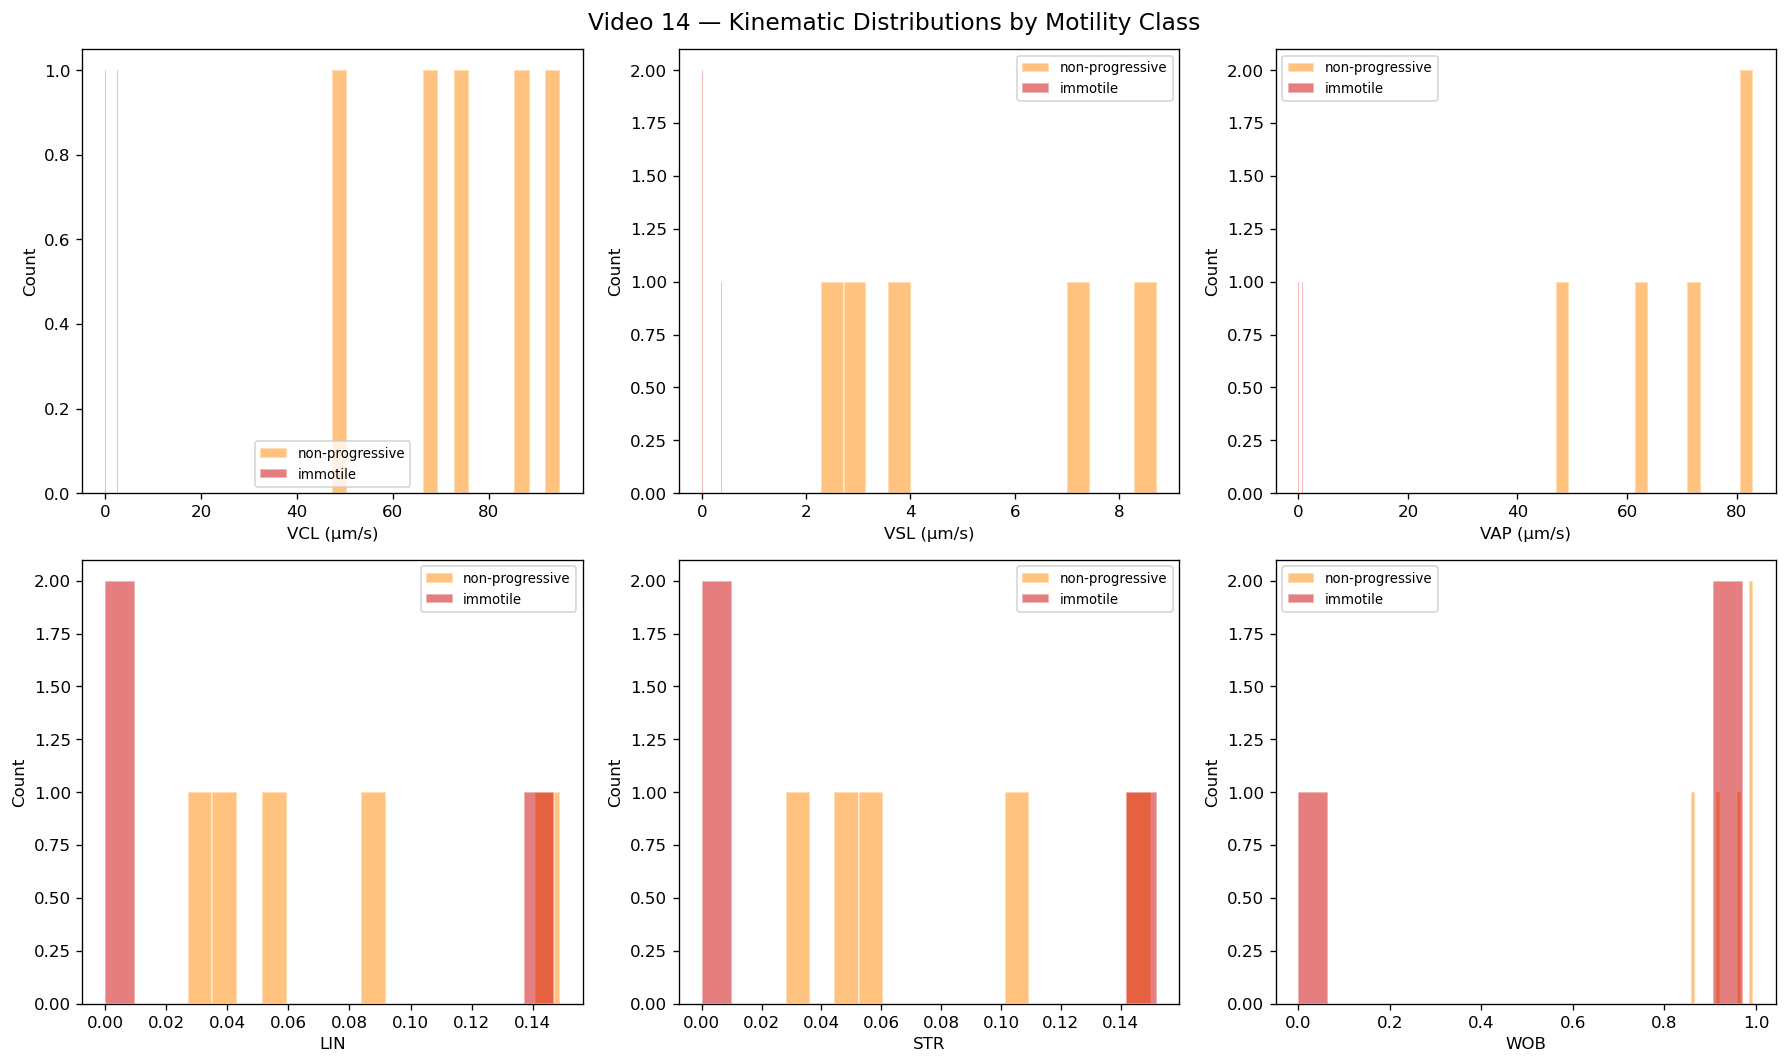

In [10]:
# Kinematic metric distributions by motility class
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
metric_cols = ["VCL", "VSL", "VAP", "LIN", "STR", "WOB"]
colors = {"progressive": "#00AA00", "non_progressive": "#FF8800", "immotile": "#CC0000"}

for ax, col in zip(axes.flat, metric_cols):
    for cat in ["progressive", "non_progressive", "immotile"]:
        subset = metrics_df[metrics_df["motility"] == cat][col]
        if not subset.empty:
            ax.hist(subset, bins=15, alpha=0.5, label=cat.replace("_", "-"),
                    color=colors[cat], edgecolor="white")
    ax.set_xlabel(col + (" (µm/s)" if col in ["VCL","VSL","VAP"] else ""))
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle(f"Video {VIDEO_ID} — Kinematic Distributions by Motility Class", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Full Motility Analysis (Integrated)

The `analyse_video()` function wraps Steps 5–7 into a single call.
It also estimates **untracked sperm** (assumed immotile) if detection JSON exists.

In [11]:
from events.detect_events import analyse_video

motility_df = analyse_video(VIDEO_ID)
motility_df.head(10)

Analysing 8 tracks from 14 ...
  Filtered: 0/8 tracks removed (0 low-conf, 0 unrealistic-VCL, 0 jitter, 0 short-duration)
  Detection data: avg 5.6 sperm/frame, avg 3.9 active tracks/frame → ~2 untracked/frame (30.0% assumed immotile)

Motility Summary – 14
  Tracked sperm:          8
  Estimated untracked:    2  (assumed immotile)
  Adjusted total:         10
  Progressive:               0  (0.0%)
  Non-progressive:           5  (43.7%)
  Immotile (adjusted):       5  (56.3%)
  Mean VCL:               46.8 µm/s
  Mean VSL:               3.2 µm/s
  Mean VAP:               43.8 µm/s

Metrics saved → /mnt/nas1/nba055-2/WP4_/sperm_analysis/outputs/events/14_motility.csv
Summary saved → /mnt/nas1/nba055-2/WP4_/sperm_analysis/outputs/events/14_summary.json


,track_id,n_frames,duration_s,VCL,VSL,VAP,LIN,STR,WOB,ALH,BCF,motility
0,1,749,14.96,86.15,2.29,83.05,0.027,0.028,0.964,0.23,12.70,non_progressive
1,2,749,14.96,68.85,2.83,63.06,0.041,0.045,0.916,0.26,9.49,non_progressive
2,3,749,14.96,0.75,0.00,0.71,0.000,0.000,0.955,0.00,1.40,immotile
3,4,721,14.40,73.42,4.00,72.48,0.055,0.055,0.987,0.08,5.97,non_progressive
4,5,721,14.40,2.65,0.39,2.58,0.147,0.152,0.971,0.00,2.01,immotile
5,6,721,14.40,47.29,7.05,46.99,0.149,0.150,0.994,0.03,4.65,non_progressive
6,7,721,14.40,0.00,0.00,0.00,0.000,0.000,0.000,0.00,0.00,immotile
7,8,619,12.36,94.94,8.72,81.46,0.092,0.107,0.858,0.60,10.36,non_progressive


In [12]:
# Load and display the saved summary JSON
summary_path = config.EVENTS_OUT / f"{VIDEO_ID}_summary.json"
with open(summary_path) as f:
    summary = json.load(f)

print("Summary JSON:")
for k, v in summary.items():
    print(f"  {k:>35}: {v}")

Summary JSON:
                                video: 14
                 tracks_before_filter: 8
                  tracks_after_filter: 8
                    filtered_low_conf: 0
                    filtered_high_vcl: 0
                      filtered_jitter: 0
              filtered_short_duration: 0
                         total_tracks: 8
                          progressive: 0
                      non_progressive: 5
                             immotile: 3
                      progressive_pct: 0.0
                  non_progressive_pct: 62.5
                         immotile_pct: 37.5
                  estimated_untracked: 2
             avg_detections_per_frame: 5.59
          avg_active_tracks_per_frame: 3.91
                   untracked_fraction: 0.3002
                       adjusted_total: 10
                    adjusted_immotile: 5
             adjusted_progressive_pct: 0.0
         adjusted_non_progressive_pct: 43.7
                adjusted_immotile_pct: 56.3
              

## 9. Visualisation

Three standard visualisations are generated per video:
1. **Trajectory map** — all sperm paths overlaid on a frame, colour-coded by motility
2. **Motility chart** — pie chart + VCL histogram + VSL-vs-VCL scatter
3. **Velocity heatmap** — spatial distribution of mean VCL

In [13]:
from visualise import plot_trajectories, plot_motility_chart, plot_velocity_heatmap

plot_trajectories(VIDEO_ID)
plot_motility_chart(VIDEO_ID)
plot_velocity_heatmap(VIDEO_ID)

# Display the generated plots
vis_dir = config.VIS_OUT
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, suffix, title in zip(axes,
    ["trajectories", "motility_chart", "velocity_heatmap"],
    ["Trajectory Map", "Motility Chart", "Velocity Heatmap"]):
    img_path = vis_dir / f"{VIDEO_ID}_{suffix}.png"
    if img_path.exists():
        img = plt.imread(str(img_path))
        ax.imshow(img)
        ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

Trajectory plot → /mnt/nas1/nba055-2/WP4_/sperm_analysis/outputs/visualisations/14_trajectories.png
Motility chart → /mnt/nas1/nba055-2/WP4_/sperm_analysis/outputs/visualisations/14_motility_chart.png
Velocity heatmap → /mnt/nas1/nba055-2/WP4_/sperm_analysis/outputs/visualisations/14_velocity_heatmap.png


## 10. Clinical Report Generation

A structured clinical report is generated from the motility summary.
This uses an offline Markdown template (or optionally GPT-4o-mini via the OpenAI API).

In [14]:
from llm.analyze import analyse_and_report

report_text = analyse_and_report(VIDEO_ID, use_llm=False)
display(Markdown(report_text))

Report saved → /mnt/nas1/nba055-2/WP4_/sperm_analysis/outputs/reports/14_report.md


# Semen Analysis Report

**Sample:** 14
**Date:** 2026-03-13 12:13
**Analysis method:** Automated CASA (YOLOv8 + BoT-SORT)

---

## Motility Classification

| Category         | Count | Percentage |
|------------------|------:|----------:|
| Progressive      |     0 |    0.0% |
| Non-progressive  |     5 |   62.5% |
| Immotile         |     3 |   37.5% |
| **Total tracked**| **8** | |

**Total motility:** 62.5% — **MEETS** WHO 2021 reference (≥42.0%)
**Progressive motility:** 0.0% — **BELOW** WHO 2021 reference (≥30.0%)

## Kinematic Parameters

| Parameter | Value |
|-----------|------:|
| VCL (µm/s) | 46.8 |
| VSL (µm/s) | 3.2 |
| VAP (µm/s) | 43.8 |
| LIN (VSL/VCL) | 0.064 |
| STR (VSL/VAP) | 0.067 |

## Interpretation

The motility parameters are below WHO 2021 reference values, suggesting reduced sperm motility.

> **Note:** This is an automated analysis. Results should be confirmed by a
> trained andrologist. Pixel-to-micron calibration (1.422 px/µm)
> should be verified for the specific microscope setup.


## 11. Evaluation Against Clinical Ground Truth

The VISEM dataset provides clinical semen analysis data for all 20 videos.
We compare our pipeline's motility percentages against the lab-measured values.

In [15]:
# Load clinical GT for this video
gt = pd.read_csv(config.RAW_DIR / "semen_analysis_data_Train.csv")
gt.columns = [c.strip() for c in gt.columns]
gt_row = gt[gt["ID"] == int(VIDEO_ID)].iloc[0]

# Pipeline predictions
pred = {
    "Progressive":     summary.get("progressive_pct", 0),
    "Non-progressive": summary.get("non_progressive_pct", 0),
    "Immotile":        summary.get("immotile_pct", 0),
}
gt_vals = {
    "Progressive":     gt_row["Progressive motility (%)"],
    "Non-progressive": gt_row["Non progressive sperm motility (%)"],
    "Immotile":        gt_row["Immotile sperm (%)"],
}

# Side-by-side comparison
comp_df = pd.DataFrame({
    "Clinical GT (%)": gt_vals,
    "Pipeline (%)": pred,
    "Δ (Pipeline − GT)": {k: round(pred[k] - gt_vals[k], 1) for k in pred},
})
display(comp_df)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(3)
width = 0.35
cats = list(gt_vals.keys())
ax.bar(x - width/2, [gt_vals[c] for c in cats], width, label="Clinical GT",
       color=["#006600", "#995500", "#880000"], alpha=0.8)
ax.bar(x + width/2, [pred[c] for c in cats], width, label="Pipeline",
       color=["#00CC00", "#FFAA33", "#FF3333"], alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(cats)
ax.set_ylabel("Percentage (%)")
ax.set_title(f"Video {VIDEO_ID} — Pipeline vs Clinical Ground Truth")
ax.legend()
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

,Clinical GT (%),Pipeline (%),Δ (Pipeline − GT)
Progressive,41.0,0.0,-41.0
Non-progressive,43.0,62.5,19.5
Immotile,16.0,37.5,21.5


## 12. Kinematic Scatter: VSL vs VCL

This plot shows the relationship between straight-line and curvilinear velocity,
with WHO classification boundaries and the three motility zones.

In [16]:
fig, ax = plt.subplots(figsize=(8, 7))

for cat, color, marker in [("progressive", "#00AA00", "o"),
                            ("non_progressive", "#FF8800", "s"),
                            ("immotile", "#CC0000", "x")]:
    subset = metrics_df[metrics_df["motility"] == cat]
    ax.scatter(subset["VCL"], subset["VSL"], c=color, marker=marker,
              s=40, alpha=0.7, label=cat.replace("_", "-"), edgecolors="white", linewidths=0.3)

# Classification boundaries
ax.axvline(config.VCL_IMMOTILE_MAX, color="red", linestyle=":", alpha=0.5,
           label=f"VCL immotile ≤ {config.VCL_IMMOTILE_MAX}")
ax.axvline(config.VCL_PROGRESSIVE_MIN, color="green", linestyle=":", alpha=0.5,
           label=f"VCL progressive ≥ {config.VCL_PROGRESSIVE_MIN}")

# Perfect linearity line
lim = max(metrics_df["VCL"].max(), metrics_df["VSL"].max()) * 1.1
ax.plot([0, lim], [0, lim], "k--", alpha=0.2, label="VSL = VCL (perfect linearity)")

ax.set_xlabel("VCL (µm/s)")
ax.set_ylabel("VSL (µm/s)")
ax.set_title(f"Video {VIDEO_ID} — VSL vs VCL by Motility Class")
ax.legend(fontsize=9, loc="upper left")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.tight_layout()
plt.show()

/tmp/ipykernel_8916/1160733680.py:7: UserWarning: You passed a edgecolor/edgecolors ('white') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(subset["VCL"], subset["VSL"], c=color, marker=marker,


## 11. Markov Chain Transition Analysis

Model motility state transitions as a Markov chain. For each track we compute
instantaneous motility in a 0.5 s sliding window, then count consecutive
state transitions across all tracks and videos.

**Outputs:** transition probability matrix, stationary distribution, per-video heatmaps.

In [17]:
# Run Markov chain analysis across all 20 videos
from markov_analysis import run_markov_analysis

T, pi, video_matrices = run_markov_analysis()

# Display transition matrix as a styled DataFrame
import pandas as pd
STATES = ["Progressive", "Non-progressive", "Immotile"]
T_df = pd.DataFrame(T, index=STATES, columns=STATES)
print("\nTransition Probability Matrix:")
display(T_df.style.format("{:.4f}").background_gradient(cmap="YlOrRd", vmin=0, vmax=1))

print(f"\nStationary Distribution:")
for s, p in zip(STATES, pi):
    print(f"  {s:>16}: {p:.4f} ({100*p:.1f}%)")

  MARKOV CHAIN TRANSITION ANALYSIS

  Loading tracks and computing per-frame motility states...
  Video  11:   57 tracks,   56568 frame-states
  Video  12:  114 tracks,   39343 frame-states
  Video  13:   77 tracks,   62642 frame-states
  Video  14:    8 tracks,    5750 frame-states
  Video  15:   40 tracks,   25202 frame-states
  Video  19:   50 tracks,   33003 frame-states
  Video  21:   66 tracks,   32444 frame-states
  Video  22:   36 tracks,   15979 frame-states
  Video  23:   11 tracks,    3227 frame-states
  Video  24:  109 tracks,   97460 frame-states
  Video  29:   11 tracks,    4799 frame-states
  Video  30:   52 tracks,   16023 frame-states
  Video  35:   61 tracks,   45750 frame-states
  Video  36:  134 tracks,   66527 frame-states
  Video  38:   43 tracks,   16808 frame-states
  Video  47:   22 tracks,    8031 frame-states
  Video  52:   47 tracks,   17953 frame-states
  Video  54:   76 tracks,   42240 frame-states
  Video  60:   52 tracks,   20401 frame-states
  Video  82

AttributeError: The '.style' accessor requires jinja2

## 12. Temporal Motility Dynamics

Track how motility class proportions change over the course of each
recording using 5-second time windows. Aggregates across all videos with
mean ± SD bands and performs linear trend regression.

In [ ]:
# Run temporal dynamics analysis across all 20 videos
from temporal_analysis import run_temporal_analysis

run_temporal_analysis()

# Display the aggregate temporal data
agg_path = config.TEMPORAL_OUT / "temporal_aggregate.csv"
if agg_path.exists():
    agg_df = pd.read_csv(agg_path)
    print(f"\nAggregate Temporal Dynamics ({len(agg_df)} windows):")
    display(agg_df.head(10).style.format("{:.1f}", subset=[
        c for c in agg_df.columns if c.startswith("pct_") or c.endswith("_mean") or c.endswith("_std")
    ]))

## 13. Interactive Chatbot — Ask Questions About the Results

The `SpermAnalysisChatbot` provides a **multi-turn conversational interface** powered
by GPT-4o-mini. It loads the video's motility summary, per-track kinematics, and
clinical ground truth into its context so it can answer detailed questions.

**Features:**
- Ask about WHO 2021 compliance, individual track velocities, clinical interpretation
- Compare across videos (load multiple with `bot.load_video(["14", "29"])`)
- Maintains conversation history for follow-up questions
- `/reset` clears history, `/load <id>` switches video

In [ ]:
from llm.chatbot import SpermAnalysisChatbot

# Create chatbot for the demo video
bot = SpermAnalysisChatbot(VIDEO_ID)
print(bot)
print(f"\nSystem prompt length: {len(bot._system_prompt):,} chars")
print(f"Videos loaded: {bot.video_ids}")

SpermAnalysisChatbot(videos=['14'], model='gpt-4o-mini', turns=0)

System prompt length: 2,721 chars
Videos loaded: ['14']


In [ ]:
# Demo question 1: WHO compliance check
response = bot.chat("Is this sample's motility normal according to WHO 2021 guidelines?")
display(Markdown(response))

No, this sample's motility is not normal according to WHO 2021 guidelines. 

- **Total motility** (progressive + non-progressive) is 0% (0 progressive + 5 non-progressive), which is below the WHO threshold of ≥ 42%.
- **Progressive motility** is 0%, which is also below the WHO threshold of ≥ 30%.

In summary, both total motility and progressive motility are significantly below the recommended reference values.

In [ ]:
# Demo question 2: Specific track analysis (follow-up — uses conversation history)
response = bot.chat("Which specific tracks show the highest velocity and what are their kinematic profiles?")
display(Markdown(response))

The specific tracks showing the highest velocity are:

1. **Track 1**
   - **VCL:** 86.15 µm/s
   - **VSL:** 2.29 µm/s
   - **VAP:** 83.05 µm/s
   - **LIN:** 0.03
   - **STR:** 0.03
   - **WOB:** 0.96
   - **ALH:** 0.23 µm
   - **BCF:** 12.70
   - **Motility:** Non-progressive

2. **Track 8**
   - **VCL:** 94.94 µm/s
   - **VSL:** 8.72 µm/s
   - **VAP:** 81.46 µm/s
   - **LIN:** 0.09
   - **STR:** 0.11
   - **WOB:** 0.86
   - **ALH:** 0.60 µm
   - **BCF:** 10.36
   - **Motility:** Non-progressive

**Summary of Kinematic Profiles:**
- **VCL (Curvilinear Velocity):** Indicates the speed of the sperm along its actual path. Track 8 has the highest VCL at 94.94 µm/s.
- **VSL (Straight-Line Velocity):** Measures the speed of the sperm in a straight line from start to finish. Track 8 has a VSL of 8.72 µm/s, which is higher than Track 1.
- **VAP (Average Path Velocity):** Represents the average speed of the sperm along its path. Track 1 has a higher VAP at 83.05 µm/s compared to Track 8.
- **LIN (Linearity):** A measure of how straight the sperm's path is; lower values indicate less linear movement. Both tracks have low LIN values, indicating non-linear movement.
- **STR (Straightness):** The ratio of VSL to VCL; lower values indicate less straight movement. Both tracks have low STR values.
- **WOB (Wobble):** Indicates the degree of deviation from a straight path; higher values suggest more wobbling motion. Track 1 has a higher WOB.
- **ALH (Amplitude of Lateral Head Displacement):** Measures the lateral movement of the sperm head; Track 8 has a higher ALH.
- **BCF (Beat Cross Frequency):** Indicates the frequency of head movements; both tracks have similar BCF values.

Overall, while Track 8 has the highest VCL, both tracks are classified as non-progressive.

In [ ]:
# Demo question 3: Clinical interpretation
response = bot.chat("What could explain the low progressive motility in this sample? What would you recommend clinically?")
display(Markdown(response))

Low progressive motility in this sample could be attributed to several factors, including:

1. **Sperm Quality Issues:**
   - **Morphological Abnormalities:** Abnormal sperm shape can affect motility.
   - **DNA Fragmentation:** High levels of DNA damage can impair sperm function.
   - **Mitochondrial Dysfunction:** Mitochondria provide energy for sperm motility; dysfunction can lead to reduced movement.

2. **Environmental Factors:**
   - **Heat Exposure:** Elevated temperatures can negatively impact sperm production and motility.
   - **Toxins:** Exposure to environmental toxins (e.g., pesticides, heavy metals) can affect sperm health.
   - **Lifestyle Factors:** Smoking, excessive alcohol consumption, and poor diet can impair sperm motility.

3. **Medical Conditions:**
   - **Hormonal Imbalances:** Conditions affecting testosterone levels can influence sperm production and motility.
   - **Infections:** Infections in the reproductive tract can lead to inflammation and affect motility.
   - **Varicocele:** Enlarged veins in the scrotum can impair sperm quality and motility.

### Clinical Recommendations:
1. **Further Evaluation:**
   - Conduct a comprehensive semen analysis to assess other parameters (e.g., sperm concentration, morphology).
   - Consider hormonal evaluations to check for hormonal imbalances.
   - Screen for infections that may require treatment.

2. **Lifestyle Modifications:**
   - Encourage a healthy lifestyle, including a balanced diet, regular exercise, and avoidance of smoking and excessive alcohol.
   - Recommend avoiding exposure to environmental toxins and managing stress.

3. **Medical Interventions:**
   - If hormonal imbalances or infections are identified, appropriate medical treatment should be initiated.
   - In cases of significant sperm quality issues, consider assisted reproductive technologies (ART) such as IVF or ICSI.

4. **Follow-Up:**
   - Schedule follow-up semen analyses after implementing lifestyle changes or treatments to monitor improvements in motility and overall sperm health.

These recommendations should be tailored to the individual patient's situation, and a consultation with a fertility specialist or urologist may be beneficial.

In [ ]:
# Multi-video comparison: load a second video and ask a cross-sample question
bot.load_video(["14", "29"])
response = bot.chat("Compare the motility profiles of video 14 and video 29. Which sample is healthier?")
display(Markdown(response))

### Motility Comparison

#### Video 14
- **Total Tracks:** 8
- **Progressive Motility:** 0 tracks (0.0%)
- **Non-progressive Motility:** 5 tracks (62.5%)
- **Immotile:** 3 tracks (37.5%)
- **Adjusted Progressive Motility:** 0 tracks (0.0%)
- **Adjusted Non-progressive Motility:** 43.7%
- **Adjusted Immotile:** 56.3%

#### Video 29
- **Total Tracks:** 11
- **Progressive Motility:** 0 tracks (0.0%)
- **Non-progressive Motility:** 1 track (9.1%)
- **Immotile:** 10 tracks (90.9%)
- **Adjusted Progressive Motility:** 0 tracks (0.0%)
- **Adjusted Non-progressive Motility:** 9.1%
- **Adjusted Immotile:** 90.9%

### Summary
- **Video 14** has a higher percentage of non-progressive motility (43.7%) compared to **Video 29** (9.1%).
- **Video 14** also has a lower percentage of immotile sperm (56.3%) compared to **Video 29** (90.9%).

### Conclusion
**Video 14** is the healthier sample, as it shows a higher proportion of non-progressive motility and a lower proportion of immotile sperm. Both samples have no progressive motility, but the overall motility profile of Video 14 is superior.

### Free-form chat

Run the cell below to start an **interactive chat session**. Type your questions
and press Enter. Type `quit` to exit.

Example questions:
- "What percentage of sperm are motile?"
- "Explain what VCL and LIN mean in simple terms"
- "Are there any tracks with unusual kinematics?"
- "Write a brief clinical summary I can give to a patient"

In [ ]:
# Interactive chat loop — type your own questions (type 'quit' to stop)
bot_interactive = SpermAnalysisChatbot(VIDEO_ID)
print(f"Chatbot ready for video {VIDEO_ID}. Type 'quit' to stop.\n")

while True:
    try:
        question = input("You: ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\nChat ended.")
        break
    if not question:
        continue
    if question.lower() in ("quit", "exit", "q"):
        print("Chat ended.")
        break
    try:
        answer = bot_interactive.chat(question)
        print(f"\nAssistant: {answer}\n")
    except Exception as e:
        print(f"\nError: {e}\n")

Chatbot ready for video 14. Type 'quit' to stop.



## Summary

This notebook demonstrated the **complete sperm motility analysis pipeline**:

1. **Data** — VISEM-Tracking dataset (640×480, 50 fps microscopy video)
2. **Detection** — YOLOv8 detector (or ground-truth annotations)
3. **Tracking** — BoT-SORT multi-object tracker → per-sperm trajectories
4. **Kinematics** — 8 WHO-standard metrics (VCL, VSL, VAP, LIN, STR, WOB, ALH, BCF)
5. **Quality filters** — remove low-confidence, jitter, short, or unrealistic tracks
6. **Classification** — progressive / non-progressive / immotile (WHO 2021)
7. **Visualisation** — trajectory maps, motility charts, velocity heatmaps
8. **Clinical report** — structured semen analysis report
9. **Evaluation** — comparison against laboratory ground truth
10. **Markov analysis** — state transition probabilities and stationary distribution
11. **Temporal dynamics** — motility proportion trends over time
12. **Interactive chatbot** — GPT-4o-mini Q&A about motility results

For batch processing, use:
```bash
python run_all_gt.py           # all 20 videos with GT annotations
python run_all_gt.py --skip-research  # skip Markov/temporal analyses
python run_pipeline.py --all   # all videos with YOLO detection
python evaluate.py             # full evaluation with plots
python markov_analysis.py      # standalone Markov chain analysis
python temporal_analysis.py    # standalone temporal dynamics
python -m llm.chatbot 14       # interactive chatbot for video 14
```